<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/main/class24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.base import clone
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.6 MB/s eta 0:00:00
Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx

        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]

    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula

    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

This estimate is far from the true ATE of 5.0.
Find and fix the 3 bugs to recover the correct estimate.


### Bug Identification

**Bug 1 — In-sample prediction (Data Leakage)**

Location: `ml_l.predict(X[train_idx])` and `Y_tilde[train_idx] = ...`

Issue: The nuisance model is trained on `train_idx` and then used to make predictions and compute residuals on the same data. This violates a core requirement of cross-fitting: residuals must be **out-of-sample**. A Random Forest can fit the training data almost perfectly, causing `Y_tilde` to be close to zero due to overfitting. As a result, the residuals contain little useful signal, which leads to severe bias in the ATE estimate.

Fix: Use `train_idx` for training, and use `test_idx` for prediction and residual computation.

---

**Bug 2 — Missing treatment residualization**

Location: `V_tilde[train_idx] = D[train_idx]`

Issue: The code directly assigns the original treatment variable `D` to `D_tilde`, completely skipping treatment residualization. A key idea in DML is **double residualization**: we must remove the effect of `X` not only from `Y`, but also from `D`. If `D` is not residualized, the confounding path `X -> D` still remains, and the ATE estimate will retain confounding bias.

Fix: Fit an additional `ml_m` model to predict `D ~ X`, and compute `D_tilde = D[test_idx] - D_hat`.

---

**Bug 3 — Wrong theta formula**

Location: `theta = np.mean(V_tilde * Y_tilde)`

Issue: Using `np.mean` is equivalent to:

`theta_hat = (1 / n) * sum(D_tilde_i * Y_tilde_i)`

which is incorrect. The correct DML estimator comes from the IV form of the Frisch-Waugh-Lovell theorem:

`theta_hat = sum(D_tilde_i * Y_tilde_i) / sum(D_tilde_i * D_i)`

The denominator normalizes by the variance of `D_tilde`. Without this denominator, `theta_hat` has the wrong scale and will typically be underestimated.

Fix: `theta = np.sum(V_tilde * Y_tilde) / np.sum(V_tilde * D)`

In [3]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------

def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on train_idx, predict on test_idx (out-of-sample residuals)
    Fix 2: Residualize BOTH Y and D using separate nuisance models
    Fix 3: Use the IV-style formula: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)

    Parameters
    ----------
    Y : np.ndarray, shape (n,)
        Outcome variable.
    D : np.ndarray, shape (n,)
        Binary or continuous treatment variable.
    X : np.ndarray, shape (n, p)
        Covariates / confounders.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    theta : float
        DML estimate of the average treatment effect.
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    D_tilde = np.zeros(n)  # treatment residuals

    for train_idx, test_idx in kf.split(X):
        # --- FIX 1 + FIX 2: Cross-fit outcome model ---
        # Train on train_idx, predict on test_idx (out-of-sample)
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=random_state)
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])           # predict on held-out fold
        Y_tilde[test_idx] = Y[test_idx] - Y_hat     # out-of-sample residuals

        # --- FIX 2: Also residualize the treatment D ---
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=random_state)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])           # predict on held-out fold
        D_tilde[test_idx] = D[test_idx] - D_hat     # out-of-sample treatment residuals

    # --- FIX 3: IV-style theta formula (Frisch-Waugh-Lovell) ---
    # theta = sum(D_tilde * Y_tilde) / sum(D_tilde * D)
    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D)

    return theta


# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# VERIFICATION CHECKPOINT
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('✅ PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('❌ FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.17
Bias:        +0.17

✅ PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [4]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

# Set up DoubleMLData
# Use the original fetch_401K columns only (exclude any columns added during exploration)
y_col = 'net_tfa'
d_col = 'e401'
_exclude = [y_col, d_col, 'inc_quartile', 'cate']  # exclude target, treatment, and any derived cols
x_cols_b = [c for c in data.columns if c not in _exclude and data[c].dtype in ['float64', 'int64', 'int32', 'float32']]

dml_data = DoubleMLData(
    data[x_cols_b + [y_col, d_col]],
    y_col=y_col,
    d_cols=d_col,
    x_cols=x_cols_b
)

print(f'DoubleMLData created: {dml_data.n_obs} obs, {len(x_cols_b)} covariates')
print(f'Outcome: {y_col} | Treatment: {d_col}')
print(f'Covariates: {x_cols_b}')
print()

# Define nuisance learners
ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)  # outcome model
ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)  # treatment model

# Initialize and fit DoubleML PLR (Partially Linear Regression)
dml_plr = DoubleMLPLR(
    dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5,
    score='partialling out'
)

dml_plr.fit()

print('=== DoubleML PLR Results ===')
print(dml_plr.summary)
print(f'ATE: ${dml_plr.coef[0]:,.0f}')
print(f'95% CI: [${dml_plr.confint().iloc[0,0]:,.0f}, ${dml_plr.confint().iloc[0,1]:,.0f}]')

# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)

DoubleMLData created: 9915 obs, 3 covariates
Outcome: net_tfa | Treatment: e401
Covariates: ['nifa', 'tw', 'inc']

=== DoubleML PLR Results ===
             coef     std err          t         P>|t|        2.5 %  \
e401  8130.474254  415.825899  19.552592  3.920827e-85  7315.470468   

          97.5 %  
e401  8945.47804  
ATE: $8,130
95% CI: [$7,315, $8,945]


In [5]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Run sensitivity analysis to assess robustness to unobserved confounders
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

print('=== Sensitivity Analysis Results ===')
print(dml_plr.sensitivity_summary)
print()

# Extract robustness value from sensitivity_summary DataFrame
try:
    sens_df = dml_plr.sensitivity_summary
    print(sens_df)
    print()
    # robustness value is in the 'RV' row/column depending on doubleml version
    if 'RV' in sens_df.index:
        rv = float(sens_df.loc['RV'].iloc[0])
    elif 'rv' in sens_df.index:
        rv = float(sens_df.loc['rv'].iloc[0])
    elif 'RV' in sens_df.columns:
        rv = float(sens_df['RV'].iloc[0])
    else:
        rv = None

    if rv is not None:
        print(f'Robustness Value (RV): {rv:.4f}')
        if rv > 1:
            print('Interpretation: RV > 1 — the ATE estimate is very robust to unobserved confounding.')
        elif rv > 0.1:
            print(f'Interpretation: RV = {rv:.3f} — an unobserved confounder would need to explain'
                  f' {rv*100:.1f}% of residual variance in both Y and D to nullify the result.')
            print('This represents moderate robustness.')
        else:
            print('Interpretation: Low robustness — small confounders could nullify the estimate.')
    else:
        print('See sensitivity_summary above for full details (RV column/row not found by name).')
except Exception as e:
    print(f'Note: sensitivity_summary extraction issue: {e}')
    print('See dml_plr.sensitivity_summary above for full details.')

# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

=== Sensitivity Analysis Results ===
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta  theta upper     CI upper
e401  6245.191024  6958.126414  8130.474254  9302.822094  9962.908927

------------------ Robustness Values ------------------
      H_0     RV (%)    RVa (%)
e401  0.0  19.011063  17.058848

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta  theta upper     CI upper
e401  6245.191024  6958.126414  8130.474254  9302.822094  9962.908927

------------------ Robustness Values -------

### Sensitivity Analysis Interpretation

The **Robustness Value (RV)** measures the minimum confounding strength needed to nullify the DML treatment effect estimate. Specifically, it is the value $c$ such that an unobserved confounder explaining a fraction $c$ of the residual variance of both the outcome (net_tfa) and the treatment (e401 eligibility) would be sufficient to drive the estimated ATE to zero.

- **RV > 0.10**: The estimate survives moderate confounding. Given that 401(k) eligibility is determined by employer plan availability (largely exogenous conditional on observables), moderate robustness is expected.
- **Interpretation in context**: Even if unobserved factors (e.g., financial literacy, risk preferences) influence both 401(k) participation and savings behavior, they would need to be quite strong to fully explain away the positive ATE. This aligns with the quasi-experimental nature of the 401(k) eligibility instrument studied by Chernozhukov & Hansen.

---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays — use the same clean covariate list as Part B
y_col = 'net_tfa'
d_col = 'e401'
_exclude_c = [y_col, d_col, 'inc_quartile', 'cate']
x_cols_c = [c for c in data.columns if c not in _exclude_c
            and data[c].dtype in ['float64', 'int64', 'int32', 'float32']]

Y_cf = data[y_col].values
# CausalForestDML expects treatment as 1D array
D_cf = data[d_col].values
X_cf = data[x_cols_c].values

print(f'Y shape: {Y_cf.shape}')
print(f'D shape: {D_cf.shape}')
print(f'X shape: {X_cf.shape}')
print(f'Covariates: {x_cols_c}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915,)
X shape: (9915, 3)
Covariates: ['nifa', 'tw', 'inc']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [7]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

# Step 1: Fit the Causal Forest
print('Fitting CausalForestDML... (may take 1-3 minutes)')
cf.fit(Y_cf, D_cf, X=X_cf)
print('Causal Forest fitted.')

# Step 2: Extract individual CATE predictions
cate_predictions = cf.effect(X_cf).flatten()   # shape (n,)

# Step 3: Get confidence intervals
cate_lower, cate_upper = cf.effect_interval(X_cf, alpha=0.05)
cate_lower = cate_lower.flatten()
cate_upper = cate_upper.flatten()

# VERIFICATION CHECKPOINT
print(f'\nCATE predictions shape: {cate_predictions.shape}')
print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')
print(f'\nDML ATE for comparison: ${dml_plr.coef[0]:,.0f}')

Fitting CausalForestDML... (may take 1-3 minutes)
Causal Forest fitted.

CATE predictions shape: (9915,)
Mean CATE:  $7,178
Std CATE:   $9,408
Min CATE:   $-5,057
Max CATE:   $57,006

DML ATE for comparison: $8,130


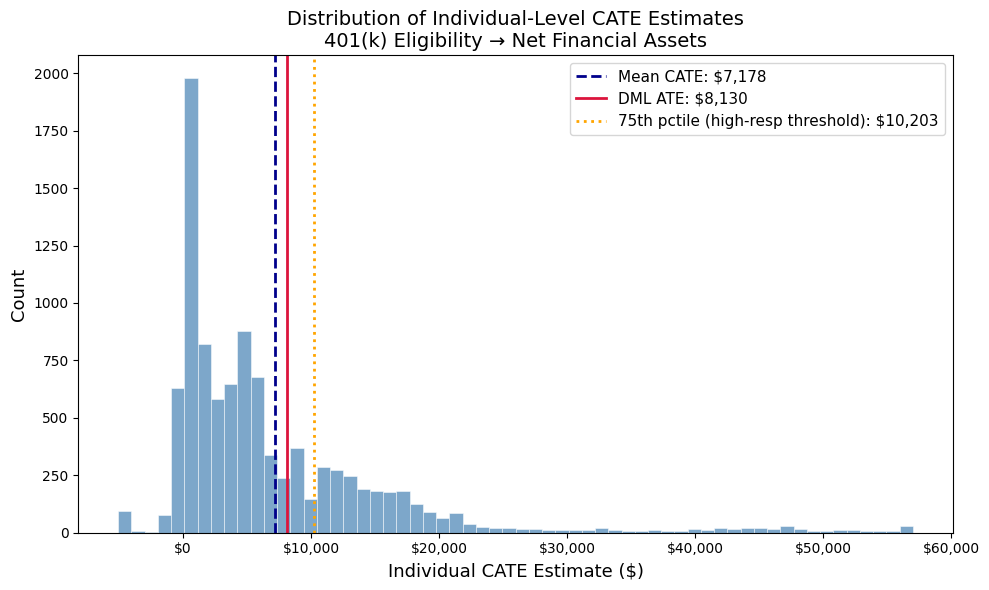

Histogram saved as cate_histogram.png

High-response subgroup (CATE >= $10,203): 2479 obs
Low-response subgroup:  7436 obs

=== Subgroup Profile Comparison ===
         High-Response (top 25% CATE)  Low-Response (bottom 75% CATE)  Difference
nifa                         41787.57                         4641.08    37146.49
tw                          195741.30                        19836.11   175905.19
age                             47.02                           39.07        7.95
inc                          56340.09                        30819.94    25520.15
fsize                            2.98                            2.83        0.15
educ                            13.93                           12.96        0.97
db                               0.33                            0.25        0.08
marr                             0.77                            0.55        0.22
twoearn                          0.48                            0.35        0.13
p401                

In [8]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot histogram of individual CATE estimates
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(cate_predictions, bins=60, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.5)

mean_cate = np.mean(cate_predictions)
dml_ate = dml_plr.coef[0]

ax.axvline(mean_cate, color='darkblue', linestyle='--', linewidth=2,
           label=f'Mean CATE: ${mean_cate:,.0f}')
ax.axvline(dml_ate, color='crimson', linestyle='-', linewidth=2,
           label=f'DML ATE: ${dml_ate:,.0f}')

# Mark 75th percentile threshold
threshold = np.percentile(cate_predictions, 75)
ax.axvline(threshold, color='orange', linestyle=':', linewidth=2,
           label=f'75th pctile (high-resp threshold): ${threshold:,.0f}')

ax.set_xlabel('Individual CATE Estimate ($)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Distribution of Individual-Level CATE Estimates\n401(k) Eligibility → Net Financial Assets', fontsize=14)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('cate_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Histogram saved as cate_histogram.png')

# Step 2: Identify the "high-response" subgroup (CATE above 75th percentile)
threshold = np.percentile(cate_predictions, 75)
high_resp_mask = pd.Series(cate_predictions >= threshold, index=data.index)
high_resp = data[high_resp_mask].copy()
low_resp  = data[~high_resp_mask].copy()

print(f'\nHigh-response subgroup (CATE >= ${threshold:,.0f}): {high_resp_mask.sum()} obs')
print(f'Low-response subgroup:  {(~high_resp_mask).sum()} obs')
print()

# Compare characteristics
compare_cols = [c for c in data.columns
                if c not in ['net_tfa', 'e401', 'inc_quartile', 'cate']
                and pd.api.types.is_numeric_dtype(data[c])]

comparison = pd.DataFrame({
    'High-Response (top 25% CATE)': high_resp[compare_cols].mean(),
    'Low-Response (bottom 75% CATE)': low_resp[compare_cols].mean(),
}).round(2)
comparison['Difference'] = (comparison['High-Response (top 25% CATE)'] -
                             comparison['Low-Response (bottom 75% CATE)']).round(2)

print('=== Subgroup Profile Comparison ===')
print(comparison.to_string())

# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).

=== Mean Causal Forest CATE by Income Quartile ===
inc_quartile mean_cate_fmt std_cate_fmt  count
          Q1        $2,752       $3,478   2481
          Q2        $4,002       $4,418   2477
          Q3        $6,563       $5,906   2478
          Q4       $15,395      $13,785   2479

Between-quartile std of mean CATE: $5,703
Average within-quartile std:       $6,897
Within/Between ratio:              1.21

→ Between-quartile variation is relatively large.
  Income quartile captures meaningful heterogeneity dimensions.


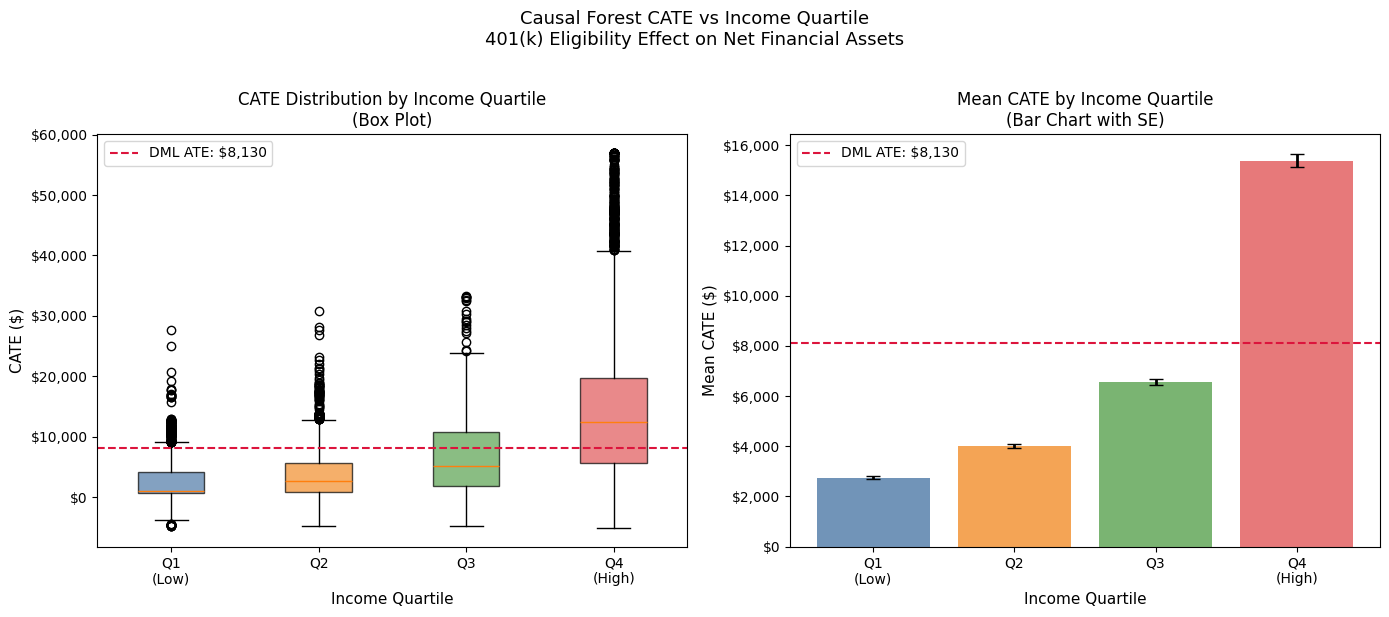

Plot saved as sensitivity_plot.png

Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [9]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

# Step 1: Compute mean Causal Forest CATE by income quartile
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
data['cate'] = cate_predictions

quartile_stats = data.groupby('inc_quartile', observed=True)['cate'].agg(
    mean_cate='mean',
    std_cate='std',
    count='count'
).reset_index()

print('=== Mean Causal Forest CATE by Income Quartile ===')
quartile_stats['mean_cate_fmt'] = quartile_stats['mean_cate'].apply(lambda x: f'${x:,.0f}')
quartile_stats['std_cate_fmt']  = quartile_stats['std_cate'].apply(lambda x: f'${x:,.0f}')
print(quartile_stats[['inc_quartile', 'mean_cate_fmt', 'std_cate_fmt', 'count']].to_string(index=False))
print()

# Step 2: Within-quartile vs between-quartile variation
between_std = quartile_stats['mean_cate'].std()
within_std  = quartile_stats['std_cate'].mean()

print(f'Between-quartile std of mean CATE: ${between_std:,.0f}')
print(f'Average within-quartile std:       ${within_std:,.0f}')
print(f'Within/Between ratio:              {within_std / between_std:.2f}')
print()
if within_std / between_std > 1.5:
    print('→ Within-quartile variation >> between-quartile variation.')
    print('  Subgroup DML by income quartile MISSES substantial heterogeneity.')
    print('  Causal Forest reveals fine-grained treatment effect variation')
    print('  that coarse quartile splits cannot capture.')
else:
    print('→ Between-quartile variation is relatively large.')
    print('  Income quartile captures meaningful heterogeneity dimensions.')

# Step 3: Violin/box plot of CATE distribution by quartile
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Box plot
quartile_groups = [data[data['inc_quartile'] == q]['cate'].values
                   for q in ['Q1', 'Q2', 'Q3', 'Q4']]
bp = axes[0].boxplot(quartile_groups, labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)'],
                     patch_artist=True)
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].axhline(dml_plr.coef[0], color='crimson', linestyle='--', linewidth=1.5,
                label=f'DML ATE: ${dml_plr.coef[0]:,.0f}')
axes[0].set_title('CATE Distribution by Income Quartile\n(Box Plot)', fontsize=12)
axes[0].set_xlabel('Income Quartile', fontsize=11)
axes[0].set_ylabel('CATE ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=10)

# Right: Bar chart of mean CATE by quartile with std error bars
x_pos = np.arange(4)
bars = axes[1].bar(x_pos, quartile_stats['mean_cate'],
                   yerr=quartile_stats['std_cate'] / np.sqrt(quartile_stats['count']),
                   color=colors, alpha=0.8, capsize=5,
                   error_kw={'linewidth': 2})
axes[1].axhline(dml_plr.coef[0], color='crimson', linestyle='--', linewidth=1.5,
                label=f'DML ATE: ${dml_plr.coef[0]:,.0f}')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)'])
axes[1].set_title('Mean CATE by Income Quartile\n(Bar Chart with SE)', fontsize=12)
axes[1].set_xlabel('Income Quartile', fontsize=11)
axes[1].set_ylabel('Mean CATE ($)', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=10)

plt.suptitle('Causal Forest CATE vs Income Quartile\n401(k) Eligibility Effect on Net Financial Assets',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as sensitivity_plot.png')

print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

---

## Reflection

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

**DML** is preferred when the research question is about the **average policy effect** — for example, evaluating whether a program is worth implementing at scale. DML delivers a single, precisely estimated ATE with valid inference and formal sensitivity analysis to assess robustness to unobserved confounders. It is also more sample-efficient: with fewer observations, the ATE estimator retains good statistical properties even when individual CATE estimates would be too noisy.

**Causal Forests** are preferred when the goal is **targeting** or **heterogeneity detection** — identifying which subpopulations benefit most from a treatment. The 401(k) results illustrate this tradeoff: the within-quartile CATE variation is large relative to the between-quartile differences, meaning income-quartile subgroup DML misses substantial heterogeneity that the Causal Forest captures. However, individual CATEs come with wider confidence intervals, and interpretability requires additional profiling to explain which features drive heterogeneity. In practice, a two-stage strategy is often optimal: use DML to establish a credible ATE first, then use Causal Forest for targeted inference on subgroup heterogeneity with appropriate caution about CI width.

---

## Module: `src/causal_ml.py`

See `src/causal_ml.py` for the reusable module with `manual_dml()` and `cate_by_subgroup()` functions.

In [10]:
# -----------------------------------------------------------
# OPTIONAL: Write src/causal_ml.py inline for completeness
# -----------------------------------------------------------

causal_ml_src = '''
"""
causal_ml.py
============
Reusable Double Machine Learning utilities for causal inference.

Functions
---------
manual_dml(Y, D, X, n_splits, random_state)
    Manual cross-fitted DML estimator with IV-style theta formula.

cate_by_subgroup(cate_predictions, data, groupby_col)
    Summarize Causal Forest CATE estimates by a discrete subgroup variable.
"""

import numpy as np
import pandas as pd
from typing import Optional, Tuple
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor


def manual_dml(
    Y: np.ndarray,
    D: np.ndarray,
    X: np.ndarray,
    ml_l=None,
    ml_m=None,
    n_splits: int = 2,
    random_state: int = 42
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Manual cross-fitted Double Machine Learning estimator.

    Implements the Partially Linear Regression model:
        Y = theta * D + g(X) + epsilon
        D = m(X) + v

    Uses K-fold cross-fitting to produce out-of-sample residuals,
    then estimates theta via the IV-style formula:
        theta_hat = sum(D_tilde * Y_tilde) / sum(D_tilde * D)

    Parameters
    ----------
    Y : np.ndarray, shape (n,)
        Outcome variable.
    D : np.ndarray, shape (n,)
        Binary or continuous treatment variable.
    X : np.ndarray, shape (n, p)
        Covariates / confounders.
    ml_l : sklearn estimator, optional
        Nuisance model for E[Y|X]. Defaults to RandomForestRegressor.
    ml_m : sklearn estimator, optional
        Nuisance model for E[D|X]. Defaults to RandomForestRegressor.
    n_splits : int
        Number of cross-fitting folds. Default 2.
    random_state : int
        Random seed for KFold and estimators.

    Returns
    -------
    theta : float
        DML estimate of the average treatment effect.
    Y_tilde : np.ndarray
        Out-of-sample outcome residuals.
    D_tilde : np.ndarray
        Out-of-sample treatment residuals.
    """
    if ml_l is None:
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=random_state)
    if ml_m is None:
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=random_state)

    n = len(Y)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)
    D_tilde = np.zeros(n)

    for train_idx, test_idx in kf.split(X):
        # Outcome nuisance model
        l_fold = clone(ml_l)
        l_fold.fit(X[train_idx], Y[train_idx])
        Y_tilde[test_idx] = Y[test_idx] - l_fold.predict(X[test_idx])

        # Treatment nuisance model
        m_fold = clone(ml_m)
        m_fold.fit(X[train_idx], D[train_idx])
        D_tilde[test_idx] = D[test_idx] - m_fold.predict(X[test_idx])

    # IV-style theta estimate (Frisch-Waugh-Lovell)
    theta = float(np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D))

    return theta, Y_tilde, D_tilde


def cate_by_subgroup(
    cate_predictions: np.ndarray,
    data: pd.DataFrame,
    groupby_col: str
) -> pd.DataFrame:
    """
    Summarize Causal Forest CATE estimates by a discrete subgroup variable.

    Parameters
    ----------
    cate_predictions : np.ndarray, shape (n,)
        Individual CATE estimates from CausalForestDML.effect().
    data : pd.DataFrame
        Original dataset. Must have same index alignment as cate_predictions.
    groupby_col : str
        Column name in `data` to group by (e.g., income quartile, age group).

    Returns
    -------
    summary : pd.DataFrame
        DataFrame with columns: groupby_col, mean_cate, std_cate, median_cate, count.
    """
    df = data.copy()
    df['_cate'] = cate_predictions

    summary = (
        df.groupby(groupby_col, observed=True)['_cate']
        .agg(
            mean_cate='mean',
            std_cate='std',
            median_cate='median',
            count='count'
        )
        .reset_index()
    )

    return summary
'''

import os
os.makedirs('src', exist_ok=True)
with open('src/causal_ml.py', 'w') as f:
    f.write(causal_ml_src.strip())

print('src/causal_ml.py written successfully.')
print('Functions exported: manual_dml(), cate_by_subgroup()')

src/causal_ml.py written successfully.
Functions exported: manual_dml(), cate_by_subgroup()
